# Bi-gram Feature extraction

In [1]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
print(df.head())
print(df.columns)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='str')


In [2]:
df = df.dropna()              # clean missing values
# df = df.sample(1000, random_state=42)  # take 1k random rows

print(df.shape)
print(df.head())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

# Feature extraction

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20000
)

X = vectorizer.fit_transform(df["review"])  
y = df["label"]

# TF_IDF result visualization

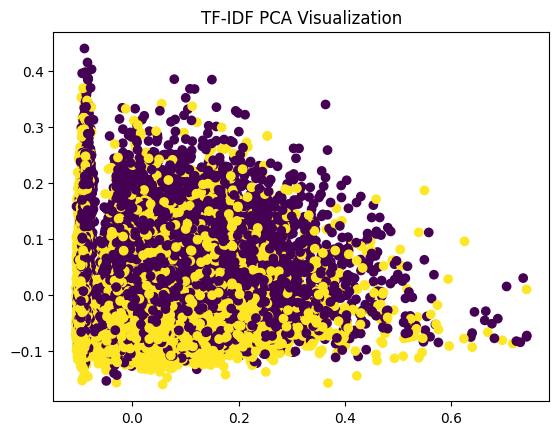

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_dense = X.toarray()  # convert sparse → dense (OK for small/medium data)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_dense)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)
plt.title("TF-IDF PCA Visualization")
plt.show()

In [7]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4183508 stored elements and shape (50000, 20000)>
  Coords	Values
  (0, 14971)	0.06918117726833162
  (0, 11360)	0.05964719221814754
  (0, 19434)	0.07022267142567154
  (0, 9865)	0.045500809261177985
  (0, 12761)	0.4855166291394108
  (0, 6173)	0.10417588849210181
  (0, 10602)	0.12216091036630783
  (0, 8673)	0.07568628577499656
  (0, 15072)	0.07812065329766305
  (0, 6330)	0.05258166097452919
  (0, 8195)	0.052368556013449946
  (0, 2306)	0.11238006633336613
  (0, 17993)	0.03526598361674844
  (0, 17241)	0.15137257154999312
  (0, 2486)	0.08412879744578766
  (0, 18773)	0.10175222684538641
  (0, 15580)	0.034671180511211444
  (0, 19207)	0.2132617967746379
  (0, 15880)	0.042477521770797395
  (0, 19760)	0.10687471494759258
  (0, 18521)	0.0664004580976799
  (0, 6587)	0.08999757075413094
  (0, 8365)	0.0705112213379213
  (0, 18120)	0.09656253181229359
  (0, 14074)	0.07210421408102369
  :	:
  (49999, 10087)	0.11772548506794973
  (49999, 187

# Convert to readable table

In [5]:
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(X.toarray(), columns=feature_names)

print(df_tfidf.head())

   000 00  000 000  000 years  10 000  10 10  10 15  10 20  10 best  \
0     0.0      0.0        0.0     0.0    0.0    0.0    0.0      0.0   
1     0.0      0.0        0.0     0.0    0.0    0.0    0.0      0.0   
2     0.0      0.0        0.0     0.0    0.0    0.0    0.0      0.0   
3     0.0      0.0        0.0     0.0    0.0    0.0    0.0      0.0   
4     0.0      0.0        0.0     0.0    0.0    0.0    0.0      0.0   

   10 bethany  10 br  ...  zoey 101  zombie bloodbath  zombie film  \
0         0.0    0.0  ...       0.0               0.0          0.0   
1         0.0    0.0  ...       0.0               0.0          0.0   
2         0.0    0.0  ...       0.0               0.0          0.0   
3         0.0    0.0  ...       0.0               0.0          0.0   
4         0.0    0.0  ...       0.0               0.0          0.0   

   zombie films  zombie flick  zombie flicks  zombie like  zombie movie  \
0           0.0           0.0            0.0          0.0           0.0   
1 

# See TF-IDF for ONE review only

In [6]:
doc_index = 0

row = X[doc_index].toarray()[0]
features = vectorizer.get_feature_names_out()

for word, score in zip(features, row):
    if score > 0:
        print(word, ":", score)

away br : 0.205632166121987
br br : 0.14569357069321873
br called : 0.2729036756304625
br say : 0.18033746364742168
br thing : 0.17595435032124268
couldn say : 0.27565146859389883
exactly happened : 0.27866133523974435
experience watching : 0.26692747052965893
far away : 0.20265073684635584
graphic violence : 0.24503809225220285
happened br : 0.23692068565874588
middle class : 0.2080688265441808
scenes violence : 0.26692747052965893
sex violence : 0.23187271203898663
use word : 0.22978977936913061
violence just : 0.27037595113592944
watching just : 0.2344902792612263
word br : 0.25923395885768


# See top words

In [7]:
import numpy as np

row = X[0].toarray()[0]
top_indices = np.argsort(row)[-10:]  

for i in top_indices:
    print(features[i], row[i])

watching just 0.2344902792612263
happened br 0.23692068565874588
graphic violence 0.24503809225220285
word br 0.25923395885768
experience watching 0.26692747052965893
scenes violence 0.26692747052965893
violence just 0.27037595113592944
br called 0.2729036756304625
couldn say 0.27565146859389883
exactly happened 0.27866133523974435


# Train/test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Evaluate

In [10]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8492


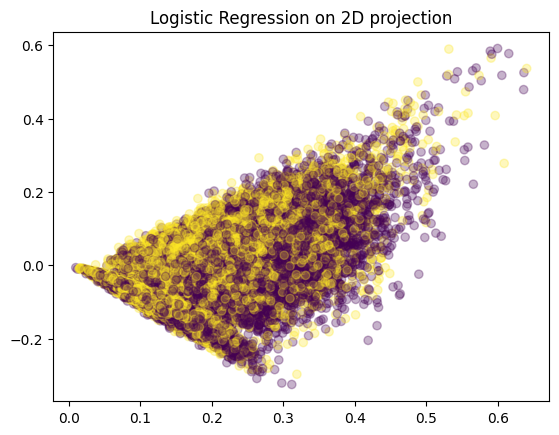

In [33]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

X_2d = TruncatedSVD(n_components=2).fit_transform(X)

model_2d = LogisticRegression()
model_2d.fit(X_2d, y)

plt.scatter(X_2d[:,0], X_2d[:,1], c=y, alpha=0.3)
plt.title("Logistic Regression on 2D projection")
plt.show()

## Inference

In [11]:
new_review = """
This movie was not fantastic. The acting was not great and the story was not engaging.
"""

# Convert text to TF-IDF features
X_new = vectorizer.transform([new_review])

# Predict sentiment
prediction = model.predict(X_new)

print(prediction[0])

1
